In [1]:
# --- Celle 1: Installer (om nødvendig) og importer ---
# Kjør bare første linje hvis du mangler pakkene.
# !pip install scikit-image imageio

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, exposure
from skimage.feature import hog




TheRock: feature length = 34596


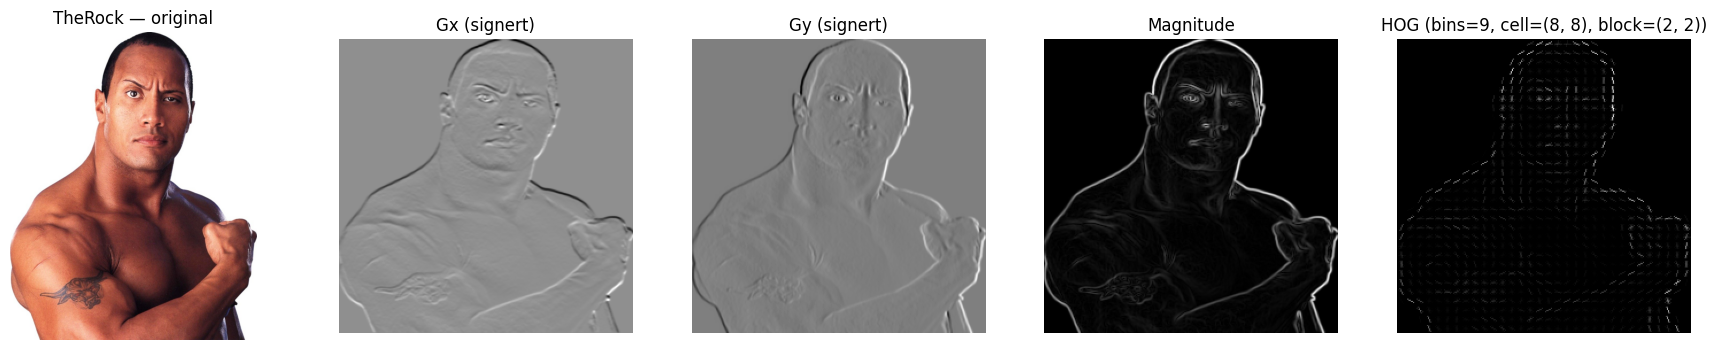

TheRock: HOG length = 34596
monster: feature length = 34596


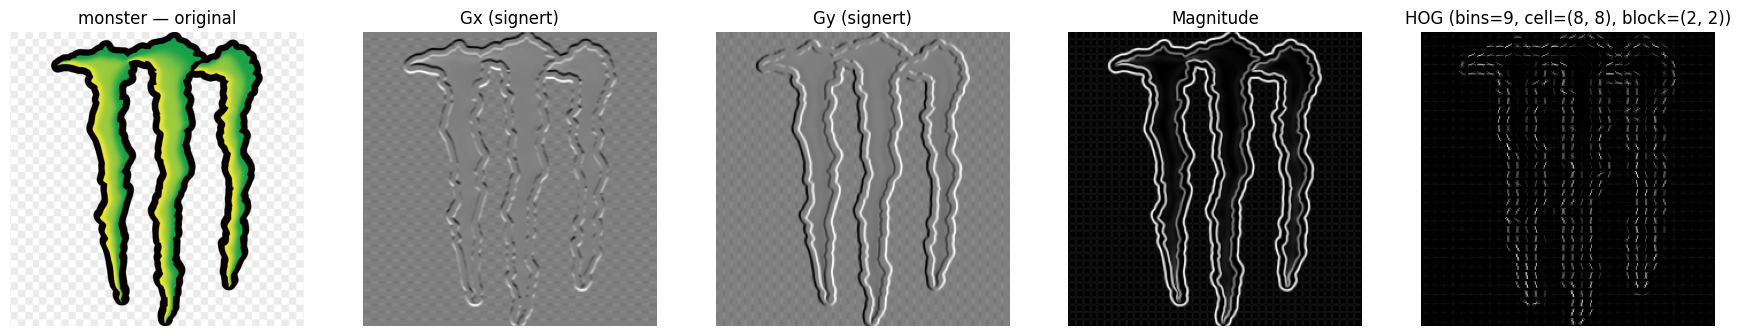

monster: HOG length = 34596
Arrow: feature length = 34596


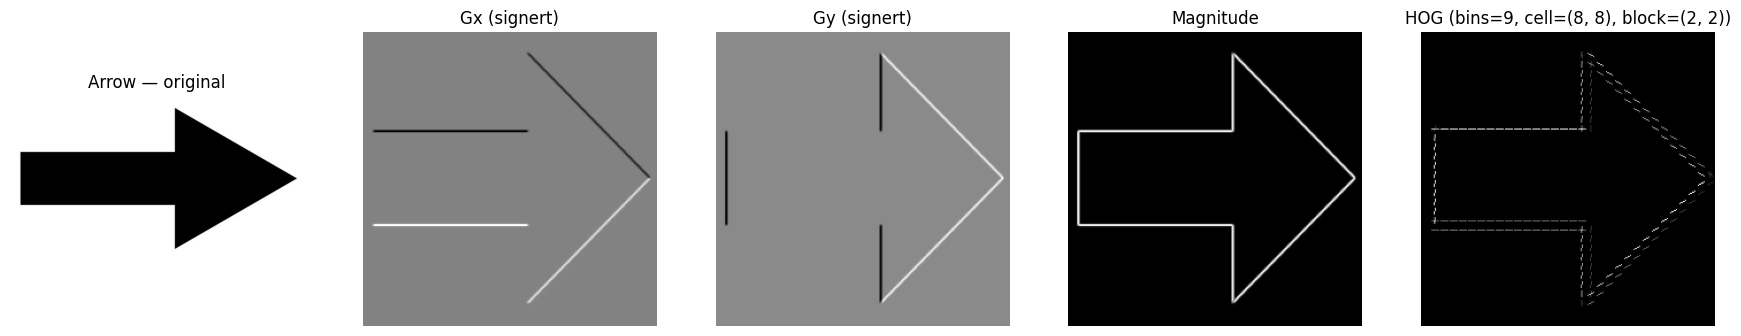

Arrow: HOG length = 34596
Mario: feature length = 34596


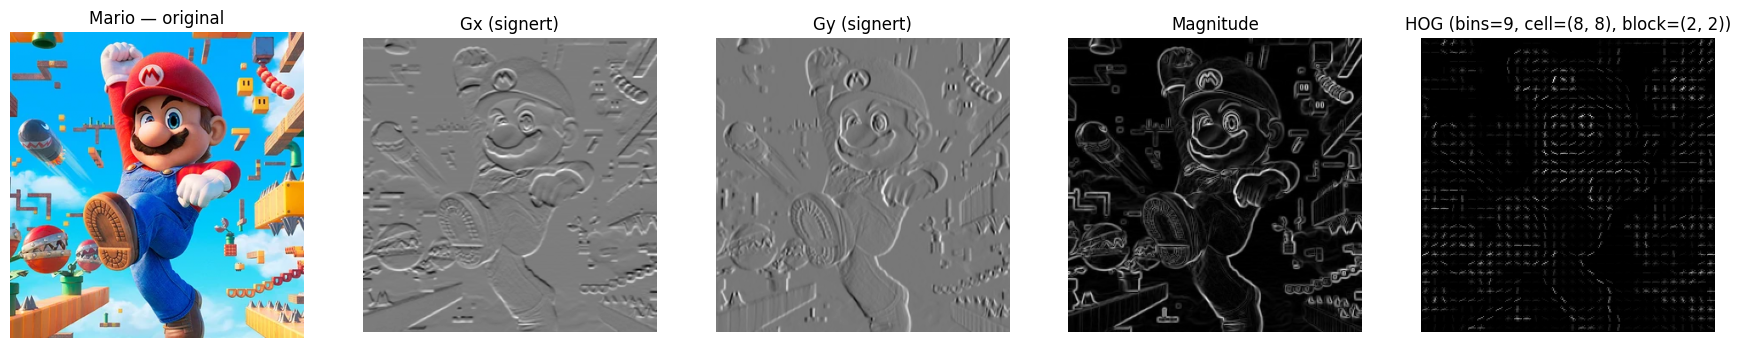

Mario: HOG length = 34596


In [60]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure, util
from skimage.feature import hog
from skimage.filters import sobel_h, sobel_v
from skimage.transform import resize

img1_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\TheRock.jpg")
img2_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\monster.png")
img3_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Arrow.png")
img4_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Mario.webp")

TARGET_SIZE = (256, 256)

def safe_read(path: Path):
    img = io.imread(path)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    return util.img_as_float(img)

def to_gray(img):
    if img.ndim == 2:
        return util.img_as_float(img)
    if img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    return color.rgb2gray(util.img_as_float(img))

def resize_gray(img_gray, size=TARGET_SIZE):
    return resize(img_gray, size, anti_aliasing=True, preserve_range=True)

def gradient_components(img):
    g = to_gray(img)
    g = resize_gray(g, TARGET_SIZE)
    gx = sobel_h(g)
    gy = sobel_v(g)
    return gx, gy

def gradient_mag(img):
    gx, gy = gradient_components(img)
    return np.hypot(gx, gy)

def hog_features_and_vis_gray(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), target_size=TARGET_SIZE):
    g = to_gray(img)
    if target_size is not None:
        g = resize_gray(g, target_size)
    features, hog_vis = hog(
        g,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True,
        channel_axis=None,
        block_norm="L2-Hys",
    )
    hog_vis = exposure.rescale_intensity(hog_vis, in_range='image')
    return features, hog_vis

def show_original_gx_gy_mag_hog(img, title, orientations=9, ppc=(8,8), cpb=(2,2)):
    feats, hog_vis = hog_features_and_vis_gray(img, orientations, ppc, cpb, target_size=TARGET_SIZE)
    gx, gy = gradient_components(img)
    mag = np.hypot(gx, gy)

    gx_vis  = exposure.rescale_intensity(gx,  in_range='image')
    gy_vis  = exposure.rescale_intensity(gy,  in_range='image')
    mag_vis = exposure.rescale_intensity(mag, in_range='image')

    fig, ax = plt.subplots(1, 5, figsize=(22, 4))
    ax[0].imshow(img, cmap="gray" if img.ndim==2 else None); ax[0].set_title(f"{title} — original"); ax[0].axis("off")
    ax[1].imshow(gx_vis, cmap="gray");  ax[1].set_title("Gx (signert)"); ax[1].axis("off")
    ax[2].imshow(gy_vis, cmap="gray");  ax[2].set_title("Gy (signert)"); ax[2].axis("off")
    ax[3].imshow(mag_vis, cmap="gray"); ax[3].set_title("Magnitude");   ax[3].axis("off")
    ax[4].imshow(hog_vis, cmap="gray"); ax[4].set_title(f"HOG (bins={orientations}, cell={ppc}, block={cpb})"); ax[4].axis("off")
    plt.show()

    print(f"{title}: HOG length = {feats.size}")
    return feats, hog_vis, gx, gy, mag

# --- Read images ---
img1 = safe_read(img1_path)
img2 = safe_read(img2_path)
img3 = safe_read(img3_path)
img4 = safe_read(img4_path)

pairs = [
    ("TheRock", img1, img1_path),
    ("monster",     img2, img2_path),
    ("Arrow",       img3, img3_path),
    ("Mario",    img4, img4_path),
]

features_list, names = [], []

for stem, img, pth in pairs:
    feats, vis = hog_features_and_vis_gray(img, target_size=TARGET_SIZE)
    print(f"{stem}: feature length = {feats.size}")

    gx, gy = gradient_components(img)
    mag = np.hypot(gx, gy)

    # show combined view
    show_original_gx_gy_mag_hog(img, stem)

    features_list.append(feats); names.append(stem)



C:\Users\hanev\AppData\Local\Temp\ipykernel_4484\3515344148.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


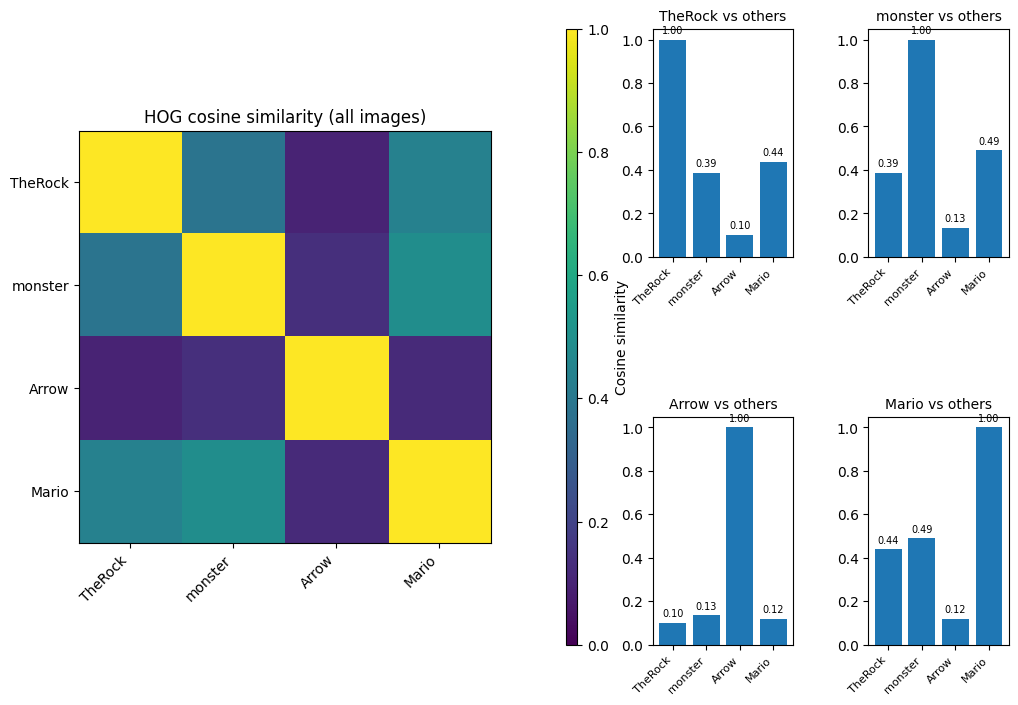

In [ ]:
import math
from matplotlib import gridspec

def cosine_similarity(a, b):
    a = a.ravel(); b = b.ravel()
    den = (np.linalg.norm(a) * np.linalg.norm(b))
    return float(a @ b / den) if den > 0 else 0.0

# Build cosine similarity matrix
n = len(features_list)
S = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(n):
        S[i, j] = cosine_similarity(features_list[i], features_list[j])


bar_cols = 2                         
bar_rows = math.ceil(n / bar_cols)   

fig = plt.figure(figsize=(12, 4 + 2*bar_rows))
gs = gridspec.GridSpec(
    bar_rows, 3 + bar_cols,          
    width_ratios=[1.2, 1.2, 0.08] + [1]*bar_cols, 
    wspace=0.6, hspace=0.7
)

ax_hm = plt.subplot(gs[:, 0:2])
im = ax_hm.imshow(S, vmin=0.0, vmax=1.0)
ax_hm.set_title("HOG cosine similarity (all images)")
ax_hm.set_xticks(range(n)); ax_hm.set_xticklabels(names, rotation=45, ha='right')
ax_hm.set_yticks(range(n)); ax_hm.set_yticklabels(names)

ax_cb = plt.subplot(gs[:, 2])
cbar = plt.colorbar(im, cax=ax_cb)
cbar.set_label("Cosine similarity")

for i in range(n):
    row = i // bar_cols
    col = (i % bar_cols) + 3  # bars start at column index 3
    ax_b = plt.subplot(gs[row, col])

    vals = S[i]
    ax_b.bar(range(n), vals)
    ax_b.set_ylim(0, 1.05)
    ax_b.set_xticks(range(n))
    ax_b.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax_b.set_title(f"{names[i]} vs others", fontsize=10)
    # optional value labels
    for k, v in enumerate(vals):
        ax_b.text(k, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()




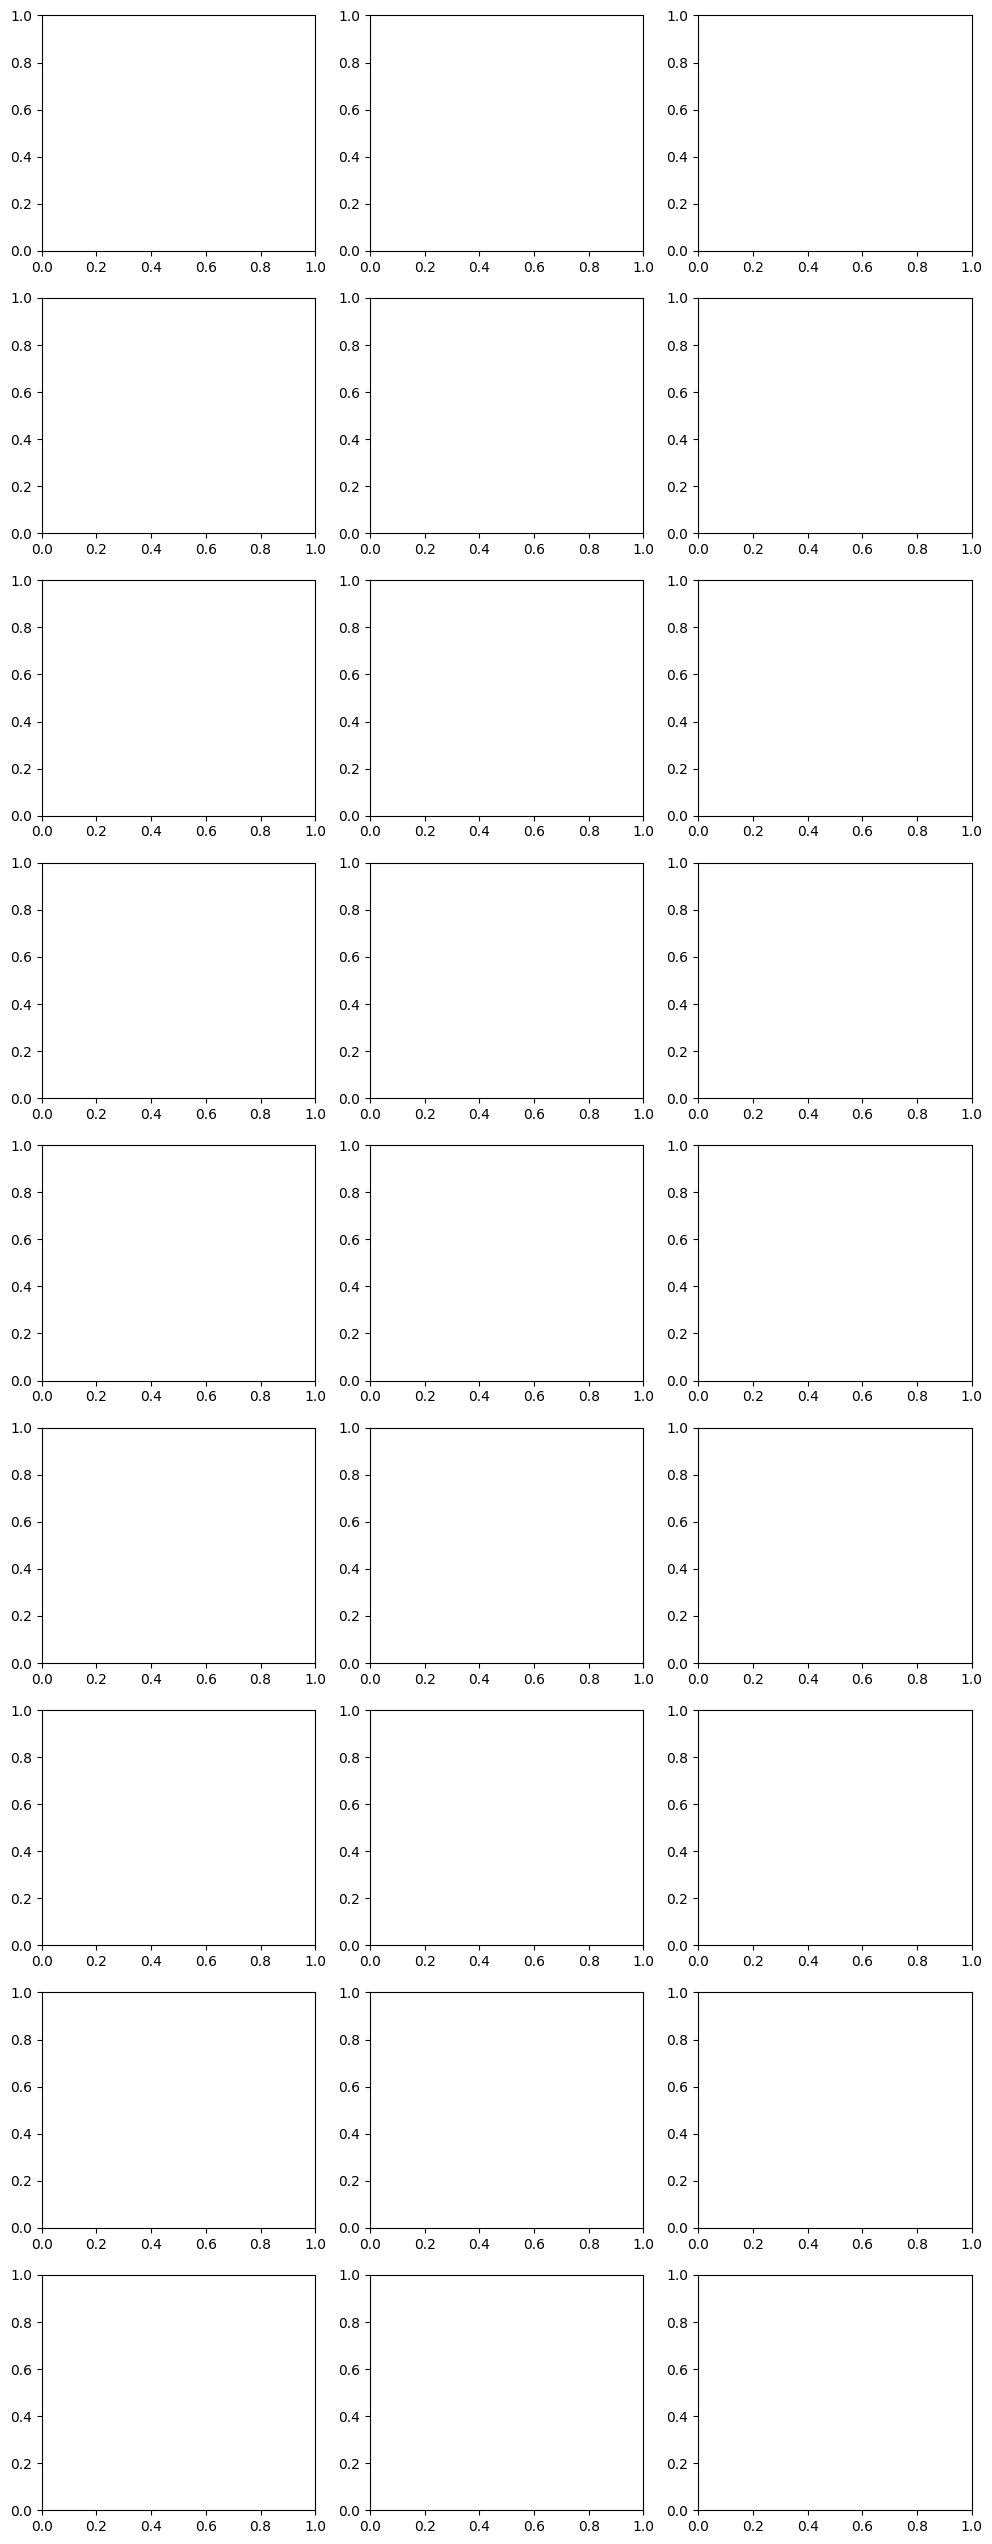

In [ ]:
# ===== HOG: strong variations + high-contrast vis + "difference vs baseline" =====
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure, util
from skimage.feature import hog
from skimage.transform import resize

# -- Images (adjust paths if needed)
img_monster = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\monster.png")
img_arrow   = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Arrow.png")
img_mario   = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Mario.webp")

IMAGES = [("monster", img_monster), ("Arrow", img_arrow), ("Mario", img_mario)]

# Use a slightly larger canvas so very large cells/blocks still make sense
TARGET_SIZE = (384, 384)

# Visualization gain (make HOG strokes brighter)
VIS_GAIN = 2.2  # try 2.0–3.0 if you want even stronger contrast

# --- Robust helpers ---
def safe_read(path: Path):
    im = io.imread(path)
    if im.ndim == 3 and im.shape[-1] == 4:
        im = color.rgba2rgb(im)
    return util.img_as_float(im)

def gray_resized(im, size=TARGET_SIZE):
    if im.ndim == 2:
        g = util.img_as_float(im)
    else:
        if im.shape[-1] == 4:
            im = color.rgba2rgb(im)
        g = color.rgb2gray(util.img_as_float(im))
    return resize(g, size, anti_aliasing=True, preserve_range=True)

def hog_feats_vis_gray(im, orientations, ppc, cpb, size=TARGET_SIZE):
    g = gray_resized(im, size)
    feats, vis = hog(
        g,
        orientations=orientations,
        pixels_per_cell=ppc,
        cells_per_block=cpb,
        visualize=True,
        channel_axis=None,
        block_norm="L2-Hys",
    )
    # boost contrast to make differences obvious
    vis = exposure.rescale_intensity(vis, in_range='image')
    vis = np.clip(vis * VIS_GAIN, 0, 1)
    return feats, vis

# --- Baseline + strong variations (MUCH bigger steps) ---
baseline = {"label": "Baseline (balanced)", "desc": "bins=9, cells=8×8, block=2×2", "O": 9, "ppc": (8,8),   "cpb": (2,2)}
param_grid = [
    baseline,
    {"label": "Tiny cells (very fine)",  "desc": "bins=18, cells=4×4,  block=2×2", "O": 18, "ppc": (4,4),   "cpb": (2,2)},
    {"label": "Huge cells (very coarse)","desc": "bins=6,  cells=32×32, block=2×2","O": 6,  "ppc": (32,32), "cpb": (2,2)},
    {"label": "Max coarse cells",        "desc": "bins=6,  cells=64×64, block=2×2","O": 6,  "ppc": (64,64), "cpb": (2,2)},
    {"label": "Tiny blocks (local only)","desc": "bins=9,  cells=8×8,   block=1×1","O": 9,  "ppc": (8,8),   "cpb": (1,1)},
    {"label": "Huge blocks (heavy norm)","desc": "bins=9,  cells=8×8,   block=4×4","O": 9,  "ppc": (8,8),   "cpb": (4,4)},
    {"label": "Very few bins (coarse θ)","desc": "bins=4,  cells=8×8,   block=2×2","O": 4,  "ppc": (8,8),   "cpb": (2,2)},
    {"label": "Many bins (fine θ)",      "desc": "bins=36, cells=8×8,   block=2×2","O": 36, "ppc": (8,8),   "cpb": (2,2)},
]

# --- Load images
images = [(name, safe_read(p)) for name, p in IMAGES]
n_images = len(images)

# --- Compute baseline HOG vis per image (for difference maps later)
baseline_vis = {}
for name, im in images:
    _, vis = hog_feats_vis_gray(im, baseline["O"], baseline["ppc"], baseline["cpb"], size=TARGET_SIZE)
    baseline_vis[name] = vis

# --- Figure 1: ORIGINALS + HOG visualizations (configs as rows, images as columns) ---
n_rows = 1 + len(param_grid)  # 1 row for originals
n_cols = n_images

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.6*n_rows))
if n_rows == 1: axes1 = np.expand_dims(axes1, axis=0)
if n_cols == 1: axes1 = np.expand_dims(axes1, axis=1)

# Row 0: originals
for c, (label, im) in enumerate(images):
    ax = axes1[0, c]
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(f"{label} — original")
    ax.axis("off")

# Subsequent rows: HOG per config
for r, cfg in enumerate(param_grid, start=1):
    for c, (label, im) in enumerate(images):
        feats, vis = hog_feats_vis_gray(im, cfg["O"], cfg["ppc"], cfg["cpb"], size=TARGET_SIZE)
        ax = axes1[r, c]
        ax.imshow(vis, cmap="gray")
        if c == 0:
            ax.set_title(f"{cfg['label']}\n({cfg['desc']}; len={feats.size})", fontsize=10)
        else:
            ax.set_title(f"len={feats.size}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

# --- Figure 2: DIFFERENCE maps vs baseline (|vis - baseline|) ---
# This makes what changed pop out visually.
fig2, axes2 = plt.subplots(len(param_grid), n_images, figsize=(4*n_cols, 3.2*len(param_grid)))
if len(param_grid) == 1: axes2 = np.expand_dims(axes2, axis=0)
if n_cols == 1: axes2 = np.expand_dims(axes2, axis=1)

for r, cfg in enumerate(param_grid):
    for c, (label, im) in enumerate(images):
        _, vis = hog_feats_vis_gray(im, cfg["O"], cfg["ppc"], cfg["cpb"], size=TARGET_SIZE)
        diff = np.abs(vis - baseline_vis[label])
        diff = exposure.rescale_intensity(diff, in_range='image')
        ax = axes2[r, c]
        ax.imshow(diff, cmap="gray")
        if c == 0:
            ax.set_title(f"Δ vs Baseline — {cfg['label']}", fontsize=10)
        else:
            ax.set_title("Δ HOG", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()
